Test all the functions one by one

In [52]:
from  Rolling_Intrinsic_QH import load_fake_data, run_optimization_quarterhours_repositioning, get_net_trades
import os
import pandas as pd
from loguru import logger
import sys
import numpy as np
import matplotlib.pyplot as plt
logger.remove()


In [3]:
logger.add(sys.stderr, level="INFO")

2

In [4]:
usecols = [#"TradeId",
           #"RemoteTradeId",
           "Side",
           "Product",
           "DeliveryStart",
           "DeliveryEnd",
           "TradePhase",
           "Price",
           "Volume",
           #"VolumeUnit",
           "ExecutionTime"
            ]
df_tst = pd.read_csv("../../real_data/Continuous_Trades-DE-20250325-20250325T235406000Z.csv",skiprows=1,
                    parse_dates=["DeliveryStart",    
                                    "DeliveryEnd",      
                                    "ExecutionTime"],
                    date_format = "ISO8601",
                    usecols = usecols
                                    )
df_tst.columns = df_tst.columns.map(lambda x: x.lower())
df_tst[df_tst.select_dtypes(include="datetime64[ns, UTC]").columns] = df_tst.select_dtypes(include="datetime64[ns, UTC]").apply(lambda x : x.dt.tz_convert("Europe/Berlin"))
df_tst = df_tst.set_index("executiontime")
filter_QH = (df_tst["product"] == 'XBID_Quarter_Hour_Power') & (df_tst["tradephase"] == "CONT")
df_tst = df_tst.loc[filter_QH]
df_tst

,side,product,deliverystart,deliveryend,tradephase,price,volume
executiontime,,,,,,,
2025-03-24 15:00:24.252000+01:00,BUY,XBID_Quarter_Hour_Power,2025-03-25 19:00:00+01:00,2025-03-25 19:15:00+01:00,CONT,158.44,0.025
2025-03-24 15:00:24.252000+01:00,SELL,XBID_Quarter_Hour_Power,2025-03-25 19:00:00+01:00,2025-03-25 19:15:00+01:00,CONT,158.44,0.025
2025-03-24 15:00:46.764000+01:00,BUY,XBID_Quarter_Hour_Power,2025-03-25 07:00:00+01:00,2025-03-25 07:15:00+01:00,CONT,136.47,0.025
2025-03-24 15:00:46.764000+01:00,SELL,XBID_Quarter_Hour_Power,2025-03-25 07:00:00+01:00,2025-03-25 07:15:00+01:00,CONT,136.47,0.025
2025-03-24 15:00:46.764000+01:00,BUY,XBID_Quarter_Hour_Power,2025-03-25 11:45:00+01:00,2025-03-25 12:00:00+01:00,CONT,89.31,0.025
...,...,...,...,...,...,...,...
2025-03-25 23:39:21.011000+01:00,BUY,XBID_Quarter_Hour_Power,2025-03-25 23:45:00+01:00,2025-03-26 00:00:00+01:00,CONT,65.00,0.100
2025-03-25 23:39:21.070000+01:00,SELL,XBID_Quarter_Hour_Power,2025-03-25 23:45:00+01:00,2025-03-26 00:00:00+01:00,CONT,51.09,0.025
2025-03-25 23:39:24.388000+01:00,BUY,XBID_Quarter_Hour_Power,2025-03-25 23:45:00+01:00,2025-03-26 00:00:00+01:00,CONT,71.09,0.125


In [5]:
def get_average_prices(
    df,side, execution_time_start, execution_time_end, end_date, min_trades=10
    ):
    # set start_of_day to end_date minus 1 day
    start_of_day = (pd.to_datetime(end_date) - pd.Timedelta(hours=2))


    # set hour and minute to 0 (europe/berlin time)
    start_of_day = start_of_day.replace(hour=0, minute=0)

    end_of_day = start_of_day

    end_of_day = end_of_day.replace(hour=23, minute=45)

    df_bucket = df.loc[execution_time_start:execution_time_end,:].copy()
    
    filter = (df_bucket.side==side) & (df_bucket.deliverystart < end_date) & (df_bucket.deliverystart>=start_of_day)
    df_bucket = df_bucket[filter]
    #logger.debug("\n"+"."*50 + "This is the bucket data" + "."*50 + "\n" + df_bucket.to_string())
    #continuehere
    result = df_bucket.groupby("deliverystart",as_index=False).filter(lambda x: len(x)>=min_trades)
    result = result.groupby("deliverystart",as_index=False)\
          .apply(func = (lambda x: (x.price * x.volume).sum() / x.volume.sum()))
    #result = VWAP from bucket
    #logger.debug("\n" + result.to_string())
    if result.shape[0]>0:
          df_vwap = pd.DataFrame(result.values, columns=["product", "price"])
    else:
         logger.error("Not enough trades above threshold for ANY Product")
         return pd.DataFrame(np.array([[np.nan,np.nan],[np.nan,np.nan]]), columns=["product", "price"])
    df_vwap = df_vwap.astype(
       { "price" : "float64",
       }
    )
   
    # set index to product
    df_vwap.set_index("product", inplace=True)
    #print(df_vwap) 
    # set index to be all 15 minute intervals from start_of_day to end_of_day, filling missing values with NaN
    df_vwap = df_vwap.reindex(pd.date_range(start_of_day, end_of_day, freq="15min"))
    logger.debug("\n"+"."*50 + "This is the VWAP" + "."*50 + "\n" + df_vwap.to_string())
    return df_vwap

In [6]:
vwap = get_average_prices(
                df_tst,
                side="BUY",
                execution_time_start=pd.Timestamp("2025-03-24 16:15:00",tz='Europe/Berlin') ,
                execution_time_end=pd.Timestamp("2025-03-24 16:30:00",tz='Europe/Berlin'),
                end_date = pd.Timestamp("2025-03-26 00:00:00",tz='Europe/Berlin'),
                min_trades=10,
            )
vwap[~vwap.price.isna()]

,price
2025-03-25 04:00:00+01:00,93.165723
2025-03-25 05:00:00+01:00,94.723333
2025-03-25 09:45:00+01:00,89.006599
2025-03-25 11:45:00+01:00,64.577866
2025-03-25 17:00:00+01:00,83.665147
2025-03-25 21:45:00+01:00,99.651148


### To Do:
- [x] Create a function to calculate VWAP 
- [x] Check Simulation
- [ ] What does optimizer do when the price curve in window is incomplete? 
- [ ] Build plotting library

#### Question: What does optimizer do when the price curve is incomplete?


##### **It makes trades based on the product prices available**


In [ ]:
### Battery Param-
threshold=0
threshold_abs_min=0
discount_rate=0
bucket_size=15
c_rate=1
roundtrip_eff=0.85
max_cycles=365


### Rolling window: The first execution window available for products on the next day is 16:00-16:15!
execution_time_start = pd.Timestamp("2025-03-24 16:15:00",tz='Europe/Berlin') 
execution_time_end = pd.Timestamp("2025-03-24 16:30:00",tz='Europe/Berlin')
end_date = pd.Timestamp("2025-03-26 00:00:00",tz='Europe/Berlin')
min_trades=10


Volume Weighted averge price based on the trades done at 16:00 - 16:15

In [ ]:
vwap = get_average_prices(
                df_tst,
                side="BUY",
                execution_time_start=pd.Timestamp("2025-03-24 16:15:00",tz='Europe/Berlin') ,
                execution_time_end=pd.Timestamp("2025-03-24 16:30:00",tz='Europe/Berlin'),
                end_date = pd.Timestamp("2025-03-26 00:00:00",tz='Europe/Berlin'),
                min_trades=10,
            )
vwap[~vwap.price.isna()]
vwap[~vwap.price.isna()]

,price
2025-03-25 04:00:00+01:00,93.17
2025-03-25 05:00:00+01:00,94.72
2025-03-25 09:45:00+01:00,89.01
2025-03-25 11:45:00+01:00,64.58
2025-03-25 17:00:00+01:00,83.67
2025-03-25 21:45:00+01:00,99.65


The initial **net_trades** dataframe, is just a Dataframe with 0's (as no trades have occured).  
This dataframe is updated continually by the full simulation as short and long positions are readjusted for the day!

In [37]:
net_trades = get_net_trades(trades = pd.DataFrame(columns=["sum_buy", "sum_sell", "net_buy", "net_sell", "product"]),
                            end_date = end_date)
net_trades

,sum_buy,sum_sell,net_buy,net_sell
2025-03-25 00:00:00+01:00,0,0,0,0
2025-03-25 00:15:00+01:00,0,0,0,0
2025-03-25 00:30:00+01:00,0,0,0,0
2025-03-25 00:45:00+01:00,0,0,0,0
2025-03-25 01:00:00+01:00,0,0,0,0
...,...,...,...,...
2025-03-25 22:45:00+01:00,0,0,0,0
2025-03-25 23:00:00+01:00,0,0,0,0
2025-03-25 23:15:00+01:00,0,0,0,0
2025-03-25 23:30:00+01:00,0,0,0,0


In [51]:
# Run first optimisation of the day
results, trades, profit = run_optimization_quarterhours_repositioning(prices_qh = vwap,
                                            execution_time = execution_time_start,
                                            cap = 1,
                                            c_rate = c_rate,
                                            roundtrip_eff = roundtrip_eff,
                                            max_cycles = max_cycles,
                                            threshold = threshold,
                                            threshold_abs_min = 0,
                                            discount_rate = 0,
                                            prev_net_trades = net_trades
                                            )

Here are the trades executed by the optimiser:

In [49]:
trades

,execution_time,side,quantity,price,product,profit
0,2025-03-24 16:15:00+01:00,buy,1.000000,64.58,2025-03-25 11:45:00+01:00,-16.145000
1,2025-03-24 16:15:00+01:00,buy,0.176471,83.67,2025-03-25 17:00:00+01:00,-3.691324
2,2025-03-24 16:15:00+01:00,sell,1.000000,99.65,2025-03-25 21:45:00+01:00,24.912500


As you can see, it has fully used the battery by buying the product **[ 1MWh, 2025-03-25 11:45:00+01:00 ]** (and a little extra probably because of inefficiency loss).  
So even when insufficient price infomation is available. It utilizes the battery fully!


In [53]:
results

,current_buy_qh,current_sell_qh,battery_soc,net_buy,net_sell,charge_sign
2025-03-25 00:00:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-25 00:15:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-25 00:30:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-25 00:45:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-25 01:00:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
2025-03-25 22:45:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-25 23:00:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-25 23:15:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0
2025-03-25 23:30:00+01:00,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: title={'center': 'SOC'}>

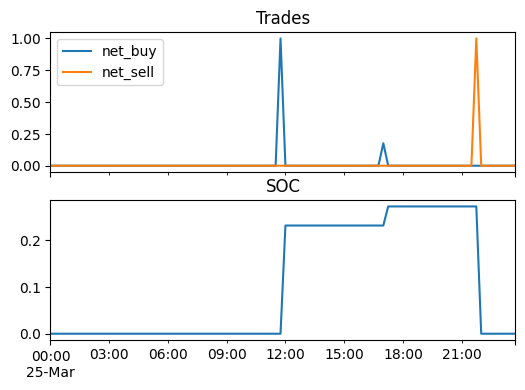

In [57]:
_,ax = plt.subplots(2,1,sharex=True,figsize=(6,4))
results.loc[:,["net_buy","net_sell"]].plot(ax=ax[0],title="Trades")

results.loc[:,"battery_soc"].plot(ax=ax[1],title="SOC")

### Old Stuff